<a href="https://colab.research.google.com/github/zakihir0/Google-Tunix-Hack---Train-a-model-to-show-its-work/blob/experiment/grpo_Gemma3_1B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Installing required packages...")
%pip install -q dotenv
%pip install -q kagglehub
%pip install -q ipywidgets
%pip install -q tensorflow
%pip install -q tensorflow_datasets
%pip install -q tensorboardX
%pip install -q transformers
%pip install -q grain
%pip install -q git+https://github.com/jax-ml/jax
%pip install git+https://github.com/google/tunix
%pip install git+https://github.com/google/qwix
%pip uninstall -q flax -y
%pip install git+https://github.com/google/flax
!pip install flax
%pip install -q huggingface_hub
%pip install -q datasets
%pip install -q 'numpy>2'

Installing required packages...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/google/tunix to /tmp/pip-req-build-8c0rfhep
  Running command git clone --filter=blob:none --quiet https://github.com/google/tunix /tmp/pip-req-build-8c0rfhep
  Resolved https://github.com/google/tunix to commit a8a69942d5020702ec064f761fbc496053152ddd
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/google/qwix to /tmp/pip-req-build-hvta0i02
  Running command git clone --filter=blob:none --quiet https://github.com/google/qwix /tmp/pip-req-build-hvta0i02
  Resolved https://github.com/google/qwix to commit 98a44ed05b66773724c7daf0f2eb40c9916f6421
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  

feat(grpo): GRPO学習パイプライン要件（tunix + Gemma3 + LoRA）を項目別に整理（追加仕様1〜4込み）

[目的・スコープ]
- tunix の GRPO で Gemma-3-1b-it を LoRA 微調整し、GSM8K系（CSV）で精度と「典型的失敗」を同時に改善する
- 学習(run)ごとに TensorBoard ログを残し、DST_ROOT に保存して run 間比較（CSV/PNG/ワイドCSV）まで自動化する
- 追加仕様(1〜4)として、<answer>欠落/不正、数の取りこぼし、単位解決、矛盾、停滞を検出して報酬に反映し、率もログ化する

[環境・実行基盤]
- Kaggle / Colab / Local を `detect_env()` で自動判定する
  - Kaggle: `/kaggle/working` を基準、Driveコピー無効
  - Colab: `/content` 基準、Drive mount を試行し可能なら Drive へコピー
  - Local: `.` 基準、Driveコピー無効
- RUN_STAMP で実行スタンプを作り、出力先（DST_ROOT）を run 単位で分離する
- 必要ディレクトリ（BASE_LOG_DIR / CKPT_DIR / TRAIN_DATA_DIR / TEST_DATA_DIR / DST_ROOT）を作成する

[依存ライブラリ・主要コンポーネント]
- JAX/Flax(nnx), optax, orbax(checkpoint), qwix(LoRA), tunix(GRPO/rollout/generation), grain(dataset)
- HuggingFace Hub: `snapshot_download()` でモデル取得
- TensorBoard: tensorboardX(SummaryWriter) + event_accumulator(読み出し)
- 解析: pandas / matplotlib

[設定（ハイパーパラメータ・挙動）]
- Model:
  - MODEL_ID = "google/gemma-3-1b-it"
  - tokenizer: GEMMA_TOKENIZER_PATH (gs://...) を使用
  - EOS_TOKENS を generation_config.json と tokenizer.eos_id() から構成する
- LoRA:
  - RANK=64, ALPHA=64
  - 対象モジュールは正規表現（q/kv/gate/up/down/attn_vec系 einsum）で指定する
- Mesh/TPU:
  - `jax.devices()` 数が 1 or 8 のみ対応（それ以外は例外）
  - MESH axis: ("fsdp","tp") を前提に mesh を構築する
- Generation:
  - MAX_PROMPT_LENGTH / TOTAL_GENERATION_STEPS / temperature/top_p/top_k
  - NUM_GENERATIONS, NUM_ITERATIONS, BETA, EPSILON を GRPOConfig に反映する
  - 追加で `GENERATION_CONFIGS`（greedy/standard/liberal）を評価用に持つ
- Training:
  - TRAIN_MICRO_BATCH_SIZE=1 を前提
  - NUM_BATCHES / TRAIN_FRACTION / NUM_EPOCHS から MAX_STEPS を決定する
  - optax warmup_cosine_decay + adamw + (任意) global norm clip を使う
  - checkpoint: SAVE_INTERVAL_STEPS / MAX_TO_KEEP を Orbax で管理する
- Verbose:
  - evaluate() で生成結果の表示を制御（VERBOSE_DEFAULT / PRINT_EVERY_N / PRINT_MAX_PER_BATCH）

[プロンプト・出力フォーマット規約]
- SYSTEM_PROMPT で `<reasoning>...</reasoning><answer>...</answer>` の厳密形式を要求する
- TEMPLATE は chat turn 形式（<start_of_turn>user/model）でプロンプトを構築する
- 抽出用正規表現:
  - `match_format`：reasoning+answer を含む全体マッチ
  - `match_numbers`：<answer>直後の数値抽出
  - `match_reasoning` / `match_answer_block`：部分抽出に使用

[データセット（GSM8K CSV, kagglehub）]
- kagglehub で "thedevastator/grade-school-math-8k-q-a" をダウンロードして TRAIN/TEST にコピーする
- CSV は `main_train.csv` / `main_test.csv` を読み、{question, answer} を構築する
- answer は "####" 以降を正解として抽出する（extract_hash_answer）
- grain.MapDataset で shuffle(seed=42) → map（prompt生成+answer整形）→ batch
- train/val split:
  - TRAIN_FRACTION=1.0 なら val無し
  - それ以外は先頭 split_i を train、残りを val とする
- test_dataset は NUM_TEST_BATCHES で切り出して評価に用いる

[モデルロード・LoRA適用]
- HuggingFace からモデルをローカルにスナップショット取得（ignore_patterns=["*.pth"]）
- `params_safetensors_lib.create_model_from_safe_tensors()` で gemma3 を構築する
- qwix の LoraProvider で LoRA を適用し、mesh 上で state を partition/shard して更新する
- mesh が実質 single の場合は sharding constraint を回避する（mesh_is_effectively_single）

[失敗検出（failure-like）と追加仕様(1〜4)]
- 失敗パターン語彙:
  - unknown系（not given/insufficient...）
  - assume系（let's assume/suppose...）
- 反復（repetition）:
  - reasoning を sentence split し、重複率が閾値以上なら fail_repeat
- excuse_bad:
  - prompt に数字が十分あるのに unknown を言う場合を追加検出する
- (1) <answer>の規律強化:
  - answer ブロックが無い → fail_answer_missing
  - answer 内の数値が 1 個でない → fail_answer_num_bad
- (2) missing addends（数の取りこぼし）:
  - prompt の "each/per/cost/$/bought..." 近傍の数値を重要数として抽出する
  - 重要数が reasoning 内に出現しない割合/個数を算出して fail_missing_addends として扱う
- (3) 単位解決 & 矛盾検出:
  - unit_resolution: each/per/apiece 系の prompt に対し reasoning 内に division の痕跡（"/", divide 等）があれば unit_resolved
  - inconsistency: "total is N" の後に "N + ..." など矛盾っぽい記述、または boxes 変数導入ミスの粗いパターンを検出する
- (4) 停滞（stagnation）:
  - reasoning の各文から (numbers + operators) の新規性を追跡し、新情報が増えない文が連続閾値以上なら fail_stagnation

[評価（evaluate）]
- sampler により各質問を生成し、複数回（num_passes）生成して best 判定を行う
- 指標:
  - accuracy（完全一致）
  - partial_accuracy（比率が 0.9〜1.1 など近傍）
  - format_accuracy（フォーマット正規表現に合致）
- 失敗率:
  - failure_rate（unknown/assume/repeat/answer_missing/answer_num_bad/excuse_bad + 追加(2)(3)(4) を統合）
  - breakdown rates（unknown_rate 等、missing_addends_rate/inconsistency_rate/stagnation_rate/unit_resolved_rate を含む）
- verbose 表示と print 間引き条件を提供する

[GRPOトレーナ・クラスタ構築]
- build_trainer_with_logdir(log_subdir, reward_fns):
  - log_dir と ckpt_dir を run 単位で作成する
  - MetricsLoggerOptions(log_dir, flush_every_n_steps=20)
  - ClusterConfig:
    - role_to_mesh: ACTOR/REFERENCE/ROLLOUT を同一 mesh に割当
    - rollout_config: max_tokens/prompt_length/kv_cache/temperature/top_p/top_k/eos_tokens
    - training_config: optimizer/eval_every_n_steps/max_steps/mini_batch_size/ckpt_root/checkpoint options
  - RLCluster を actor=lora_policy, reference=gemma3, tokenizer=tokenizer で構築する
  - GRPOLearner に reward_fns と GRPOConfig を渡す

[TensorBoard 追加ログ（Policy B）]
- tunix が出す log_dir に同居させて追記ログする（同一 run の可視化統合）
- SummaryWriter を log_dir ごとにキャッシュし、flush/close を管理する
- 追加スカラー（例）:
  - global/eval/accuracy, partial_accuracy, format_accuracy, num_correct, total
  - global/eval/failure_rate + breakdown（unknown/assume/...）
  - 追加(2)(3)(4) の rate（missing_addends_rate, inconsistency_rate, stagnation_rate, unit_resolved_rate）

[報酬関数セット（Reward functions / sets）]
- フォーマット:
  - match_format_exactly: 厳密一致で +3
  - match_format_approximately: タグの個数・位置で段階スコア
- 正解:
  - check_answer: 抽出答と真値の一致/近似/乖離でスコア
  - check_numbers: <answer>直後の数値抽出の一致でスコア
- 推論品質:
  - reward_step_logic: first/then/therefore などの出現で加点
  - reward_self_correction: wait/actually/however 等で加点
- (3) unit resolution:
  - reward_unit_resolution: unit-rate prompt で division の痕跡があれば加点
- (1〜4) penalty:
  - penalty_failure_like:
    - <answer>欠落/数値不正を強めに減点
    - unknown/assume/repeat/excuse_bad を減点
    - missing addends を欠落比率に応じて追加減点（上限あり）
    - inconsistency / stagnation を追加減点
    - 最終的に [-6.0, 0.0] に clamp
- reward_sets:
  - "discipline_v2" として上記群を組み合わせて学習に使用する
- reward_set_description():
  - run ごとに報酬関数名一覧を保存・可視化に使う

[実行フロー（Run orchestration）]
- baseline_inference:
  - 学習なしで test を evaluate し、TB に step=0 で指標と失敗率を記録する
- train_and_eval:
  - 指定 reward_fns で learner.train(train_ds, val_ds) を実行する（with mesh）
  - その後 test evaluate を行い、TB に step=MAX_STEPS で記録する
- 実行箇所は「1箇所」に集約:
  - 00_baseline → reward_sets を順に学習→評価
  - run_logdirs / run_reward_desc を保持して後段の比較に渡す

[成果物の保存・コピー（DST_ROOT）]
- SRC_DIRS:
  - tensorboard_grpo: BASE_LOG_DIR
  - ckpts: CKPT_DIR
- copy_tree で DST_ROOT 配下に丸ごと複製する（dirs_exist_ok=True）
- analysis_outputs を DST_ROOT に作成し、reward_sets_used.json を保存する

[Run比較・解析出力（DST_ROOTから再構築）]
- TB_ROOT = DST_ROOT/tensorboard_grpo を探索し、run ディレクトリ一覧を取得する
- event_accumulator で events.out.tfevents.* を読み出し、(tag, step, value, wall_time) を long 形式で結合する
- 出力:
  - ALL_runs_scalars_long.csv（全run結合のlongテーブル）
  - compare_plots_all_tags.png（指定tag群を1枚のPNGにまとめる）
  - 各tagの wide CSV（step×run のピボット）を OUT_DIR に出力する
- compare PNG の要件:
  - 指定タグ（DEFAULT_COMPARE_TAGS）を可能な限り描画し、欠損タグは warn してスキップする
  - 図の footer に run→reward_set_description を整形して載せる（textwrap で折返し）
  - smoothing（rolling mean）と step_max、run 選択（SELECT_RUNS）をオプションで持つ

[比較対象タグ（DEFAULT_COMPARE_TAGS）の要件]
- 精度系:
  - global/eval/accuracy, partial_accuracy, format_accuracy, num_correct, total
- RLログ系（tunix側含む）:
  - global/train/eval rewards sum
  - actor train/eval: loss, kl, perplexity
  - completions mean_length（train/eval）
- failure-like系:
  - failure_rate, unknown_rate, assume_rate, repeat_rate, answer_missing_rate, answer_num_bad_rate, excuse_bad_rate
- 追加(2)(3)(4)系:
  - missing_addends_rate, inconsistency_rate, stagnation_rate, unit_resolved_rate

[ENV] colab
Mounted at /content/drive
[Drive] mounted: True
[PATHS]
 BASE_LOG_DIR: /tmp/content/tmp/tensorboard/grpo
 CKPT_DIR    : /tmp/content/ckpts
 TRAIN_DATA_DIR: /content/data/train
 TEST_DATA_DIR : /content/data/test
 DST_ROOT    : /content/drive/MyDrive/grpo_runs/20260109_093436


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:93: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Using Colab cache for faster access to the 'grade-school-math-8k-q-a' dataset.
Copied main_test.csv → /content/data/train/main_test.csv
Copied main_train.csv → /content/data/train/main_train.csv
Copied socratic_train.csv → /content/data/train/socratic_train.csv
Copied socratic_test.csv → /content/data/train/socratic_test.csv
Using Colab cache for faster access to the 'grade-school-math-8k-q-a' dataset.
Copied main_test.csv → /content/data/test/main_test.csv
Copied main_train.csv → /content/data/test/main_train.csv
Copied socratic_train.csv → /content/data/test/socratic_train.csv
Copied socratic_test.csv → /content/data/test/socratic_test.csv
dataset contains batches: (3364, 374, 64)
{'answer': array(['3'], dtype='<U1'),
 'prompts': array(['<start_of_turn>user\nYou are given a problem. First, think about the problem and provide your reasoning. Place it between <reasoning> and </reasoning>. Then, provide the final answer (i.e., just one numerical value) between <answer> and </answer>.\n\

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

...

  0%|          | 0/64 [00:00<?, ?it/s]

Question:	Mr Hezekiah had 20 trucks from his store supplying fertiliser to different farmers in his hometown dispatched for delivery on a particular day. Each truck was carrying 20 tons of fertiliser packed in bags. Two hours after the trucks had departed for delivery, Mr Hezekiah got the news that a quarter of the number of lorries dispatched for delivery had mechanical failures on the road and could not deliver the fertilisers to the farmers. Calculate the total number of tons of fertiliser that reached the farmers that day?
Correct Answer:	300
Response:	reasoning:
The problem states that each truck carried 20 tons of fertiliser. Mr. Hezekiah dispatched 20 trucks. Therefore, the total amount of fertiliser initially planned was 20 trucks * 20 tons/truck = 400 tons.
Two hours after the trucks departed, a quarter of the lorries failed. This means that the number of lorries that failed is (1/4) * 20 = 5 lorries.
Each lorry carried 20 tons of fertiliser. So, the total amount of fertiliser

Actor Training:   0%|          | 0/3364 [00:00<?, ?step/s]

  0%|          | 0/64 [00:00<?, ?it/s]

Question:	Mr Hezekiah had 20 trucks from his store supplying fertiliser to different farmers in his hometown dispatched for delivery on a particular day. Each truck was carrying 20 tons of fertiliser packed in bags. Two hours after the trucks had departed for delivery, Mr Hezekiah got the news that a quarter of the number of lorries dispatched for delivery had mechanical failures on the road and could not deliver the fertilisers to the farmers. Calculate the total number of tons of fertiliser that reached the farmers that day?
Correct Answer:	300
Response:	
<reasoning>
The problem states that each truck carried 20 tons of fertiliser. There were 20 trucks dispatched.  After two hours, a quarter of the lorries failed, meaning that only 20 / 4 = 5 lorries remained operational.  Since each of the 5 lorries carried 20 tons of fertiliser, the total amount of fertiliser delivered is 5 * 20 = 100 tons.
</reasoning>
<answer>100</answer>
--------------------------------------------------
Questio

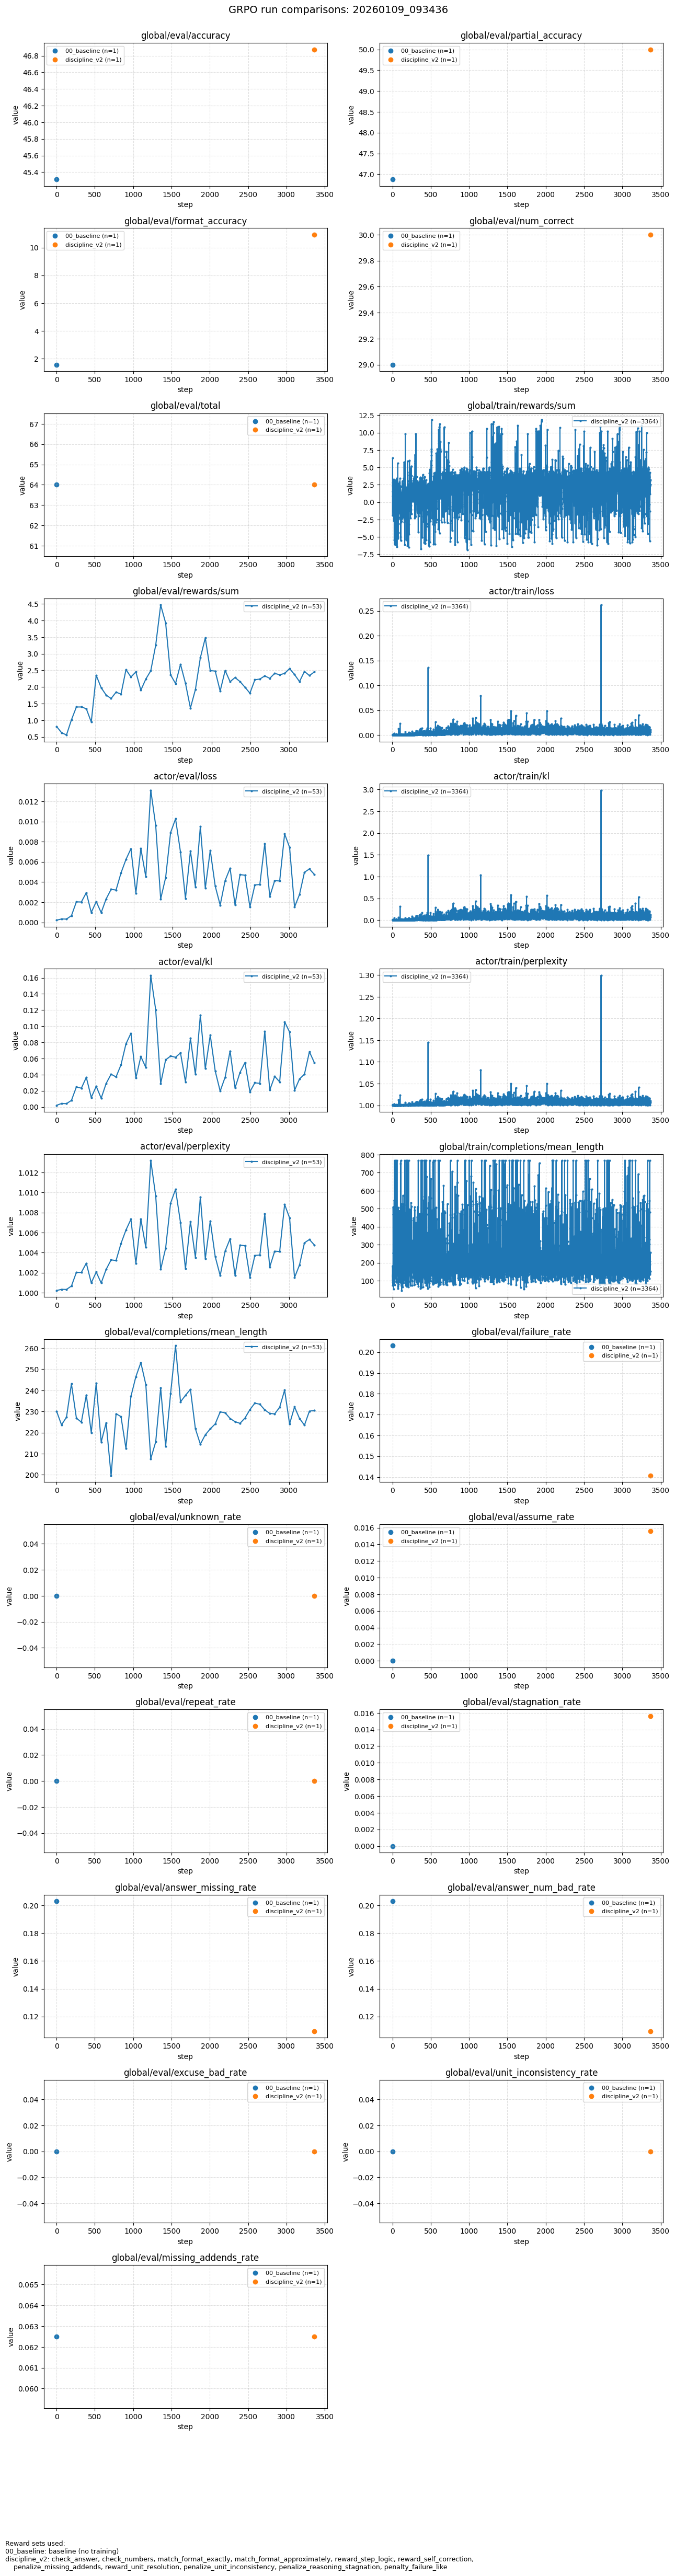

[OK] saved PNG: /content/drive/MyDrive/grpo_runs/20260109_093436/analysis_outputs/compare_plots_all_tags.png
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_093436/analysis_outputs/global__eval__accuracy_wide.csv
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_093436/analysis_outputs/global__eval__partial_accuracy_wide.csv
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_093436/analysis_outputs/global__eval__format_accuracy_wide.csv
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_093436/analysis_outputs/global__eval__num_correct_wide.csv
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_093436/analysis_outputs/global__eval__total_wide.csv
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_093436/analysis_outputs/global__train__rewards__sum_wide.csv
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_093436/analysis_outputs/global__eval__rewards__sum_wide.csv
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_093436/analysis_outputs/actor__train__loss_wide.csv

In [ ]:
# ============================================================
# GRPO (tunix) + Custom rewards + Policy B (log ACC + FailureStats into TensorBoard)
# + Verbose generation printing (optional)
# + "failure-like" rate statistics (unknown/assume/repeat/answer-format issues)
# + Copy logs -> (Colab: Google Drive) / (Kaggle: /kaggle/working)
# + Compare runs from the saved root (merged CSV + wide CSVs + ONE PNG)
#   - PNG also shows reward-function sets used per run (figure footer)
#
# ✅ Added (1)~(4):
# (1) Stronger penalties for missing/invalid answer (already existed; strengthened)
# (2) penalize_missing_addends: money-ish numbers in prompt must be accounted for in completion
# (3) reward_unit_resolution + penalize_unit_inconsistency (simple, regex-based)
# (4) improved stagnation detection + logging (stagnation_rate) + penalty hook
#
# ✅ Added (5):
# (5) Export wrong answers in eval to CSV for each run
#
# Notes:
# - Writes extra scalars into SAME log_dir as tunix:
#   global/eval/accuracy, global/eval/partial_accuracy, global/eval/format_accuracy,
#   global/eval/num_correct, global/eval/total
#   + global/eval/failure_rate and breakdown rates
# ============================================================

# ============================================================
# 0) Environment switch (Kaggle vs Colab) + Paths + (optional) Drive mount
# ============================================================
import os, sys, time
from pathlib import Path

def detect_env() -> str:
  if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or os.path.exists("/kaggle/working"):
    return "kaggle"
  try:
    import google.colab  # noqa
    return "colab"
  except Exception:
    return "local"

ENV = detect_env()
print("[ENV]", ENV)

RUN_STAMP = time.strftime("%Y%m%d_%H%M%S")

if ENV == "kaggle":
  WORK_DIR = Path("/kaggle/working")
  TMP_DIR  = WORK_DIR / "tmp"
  OUT_ROOT = WORK_DIR / "grpo_runs" / RUN_STAMP

  BASE_LOG_DIR = str(TMP_DIR / "tensorboard" / "grpo")
  CKPT_DIR     = str(TMP_DIR / "ckpts")
  TRAIN_DATA_DIR = str(WORK_DIR / "data" / "train")
  TEST_DATA_DIR  = str(WORK_DIR / "data" / "test")

  ENABLE_DRIVE_COPY = False
  DST_ROOT = str(OUT_ROOT)

elif ENV == "colab":
  WORK_DIR = Path("/content")
  TMP_DIR  = Path("/tmp/content")
  TRAIN_DATA_DIR = str(WORK_DIR / "data" / "train")
  TEST_DATA_DIR  = str(WORK_DIR / "data" / "test")

  BASE_LOG_DIR = str(TMP_DIR / "tmp" / "tensorboard" / "grpo")
  CKPT_DIR     = str(TMP_DIR / "ckpts")

  # (Colab) Mount Google Drive (once)
  ENABLE_DRIVE_COPY = True
  try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
      drive.mount("/content/drive")
    print("[Drive] mounted:", Path("/content/drive/MyDrive").exists())
  except Exception as e:
    print("[Drive] mount skipped:", e)
    ENABLE_DRIVE_COPY = False

  if ENABLE_DRIVE_COPY:
    DST_ROOT = str(Path("/content/drive/MyDrive/grpo_runs") / RUN_STAMP)
  else:
    DST_ROOT = str((WORK_DIR / "grpo_runs" / RUN_STAMP))

else:
  WORK_DIR = Path(".").resolve()
  TMP_DIR  = WORK_DIR / "tmp"
  BASE_LOG_DIR = str(TMP_DIR / "tensorboard" / "grpo")
  CKPT_DIR     = str(TMP_DIR / "ckpts")
  TRAIN_DATA_DIR = str(WORK_DIR / "data" / "train")
  TEST_DATA_DIR  = str(WORK_DIR / "data" / "test")
  ENABLE_DRIVE_COPY = False
  DST_ROOT = str((WORK_DIR / "grpo_runs" / RUN_STAMP))

Path(BASE_LOG_DIR).mkdir(parents=True, exist_ok=True)
Path(CKPT_DIR).mkdir(parents=True, exist_ok=True)
Path(TRAIN_DATA_DIR).mkdir(parents=True, exist_ok=True)
Path(TEST_DATA_DIR).mkdir(parents=True, exist_ok=True)
Path(DST_ROOT).mkdir(parents=True, exist_ok=True)

print("[PATHS]")
print(" BASE_LOG_DIR:", BASE_LOG_DIR)
print(" CKPT_DIR    :", CKPT_DIR)
print(" TRAIN_DATA_DIR:", TRAIN_DATA_DIR)
print(" TEST_DATA_DIR :", TEST_DATA_DIR)
print(" DST_ROOT    :", DST_ROOT)

# ============================================================
# 1) Imports
# ============================================================
import csv, json, shutil, glob, math, re, textwrap
from pprint import pprint

from flax import nnx
import grain
import jax
import optax
import qwix
from tqdm.auto import tqdm
from huggingface_hub import snapshot_download
from orbax import checkpoint as ocp

from tunix.generate import sampler as sampler_lib
from tunix.generate import tokenizer_adapter as tokenizer_lib
from tunix.models.gemma3 import model as gemma_lib
from tunix.models.gemma3 import params_safetensors as params_safetensors_lib
from tunix.rl import rl_cluster as rl_cluster_lib
from tunix.rl.grpo.grpo_learner import GRPOConfig, GRPOLearner
from tunix.rl.rollout import base_rollout
from tunix.sft import metrics_logger

from tensorboardX import SummaryWriter
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 2) Configs
# ============================================================
MODEL_ID = "google/gemma-3-1b-it"
GEMMA_TOKENIZER_PATH = "gs://gemma-data/tokenizers/tokenizer_gemma3.model"

TRAIN_FRACTION = 0.9

# LoRA
RANK  = 64
ALPHA = 64.0

# Mesh
NUM_TPUS = len(jax.devices())
if NUM_TPUS == 8:
  MESH_COUNTS = (1, 4)
elif NUM_TPUS == 1:
  MESH_COUNTS = (1, 1)
else:
  raise ValueError(f"Unsupported number of TPUs: {NUM_TPUS}")

MESH = [
    MESH_COUNTS,
    ("fsdp", "tp"),
]

# GRPO generation
MAX_PROMPT_LENGTH       = 256
TOTAL_GENERATION_STEPS  = 768
TEMPERATURE             = 0.9
TOP_P                   = 1.0
TOP_K                   = 50
NUM_GENERATIONS         = 2
NUM_ITERATIONS          = 1
BETA                    = 0.08
EPSILON                 = 0.2

# Training
TRAIN_MICRO_BATCH_SIZE  = 1
NUM_BATCHES             = 3738
NUM_TEST_BATCHES        = 64
EVAL_EVERY_N_STEPS      = 64
NUM_EPOCHS              = 1
MAX_STEPS = int(NUM_BATCHES * NUM_ITERATIONS * TRAIN_FRACTION * NUM_EPOCHS)

LEARNING_RATE = 3e-6
B1 = 0.9
B2 = 0.99
WEIGHT_DECAY = 0.1
WARMUP_STEPS = 0.1 * MAX_STEPS
MAX_GRAD_NORM = 0.1

SAVE_INTERVAL_STEPS = 500
MAX_TO_KEEP   = 4

GENERATION_CONFIGS = {
    "greedy":   {"temperature": None, "top_k": 1,    "top_p": None},
    "standard": {"temperature": 0.7,  "top_k": 50,   "top_p": 0.95},
    "liberal":  {"temperature": 0.85, "top_k": 2000, "top_p": 1.0},
}

# Verbose printing controls (for evaluate())
VERBOSE_DEFAULT = True
PRINT_EVERY_N = 1
PRINT_MAX_PER_BATCH = None

# Failure-stat controls
FAIL_REPETITION_DUP_FRAC = 0.35
FAIL_REPETITION_MIN_SENT = 6

# (4) stagnation controls
FAIL_STAGNATION_MIN_SENT = 6
FAIL_STAGNATION_NO_NEW_MATH_STREAK = 4  # consecutive sentences with no "new math tokens"
FAIL_STAGNATION_SIM_MATH_FRAC = 0.6     # too many same math-token-sets

# Prompt format
reasoning_start = "<reasoning>"
reasoning_end   = "</reasoning>"
solution_start  = "<answer>"
solution_end    = "</answer>"

SYSTEM_PROMPT = f"""You are given a problem. First, think about the problem and provide your reasoning. Place it between {reasoning_start} and {reasoning_end}. Then, provide the final answer (i.e., just one numerical value) between {solution_start} and {solution_end}."""

TEMPLATE = """<start_of_turn>user
{system_prompt}

{question}<end_of_turn>
<start_of_turn>model
"""

# ============================================================
# 3) Dataset (Kaggle GSM8K csv via kagglehub)
# ============================================================
def extract_hash_answer(text: str) -> str | None:
  if "####" not in text:
    return None
  return text.split("####")[1].strip()

def download_kaggle_dataset(target_dir="./data/gsm8k"):
  os.makedirs(target_dir, exist_ok=True)
  import kagglehub
  if ENV == "kaggle":
    try:
      kagglehub.login()
    except Exception:
      pass
  src = kagglehub.dataset_download("thedevastator/grade-school-math-8k-q-a")
  src = Path(src)
  dst = Path(target_dir)
  for csv_file in src.glob("*.csv"):
    shutil.copy2(csv_file, dst / csv_file.name)
    print(f"Copied {csv_file.name} → {dst/csv_file.name}")
  return target_dir

def get_dataset(data_dir, split="train") -> grain.MapDataset:
  os.makedirs(data_dir, exist_ok=True)
  kaggle_dir = download_kaggle_dataset(data_dir)
  file_name = "main_" + split + ".csv"
  csv_path = os.path.join(kaggle_dir, file_name)

  data = []
  with open(csv_path, newline="", encoding="utf-8") as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
      data.append({"question": row["question"], "answer": row["answer"]})

  def _as_text(v):
    return v if isinstance(v, str) else v.decode("utf-8")

  dataset = (
      grain.MapDataset.source(data)
      .shuffle(seed=42)
      .map(
          lambda x: {
              "prompts": TEMPLATE.format(
                  system_prompt=SYSTEM_PROMPT,
                  question=_as_text(x["question"]),
              ),
              "question": _as_text(x["question"]),
              "answer": extract_hash_answer(_as_text(x["answer"])),
          }
      )
  )
  return dataset

dataset_all = get_dataset(TRAIN_DATA_DIR, "train").batch(TRAIN_MICRO_BATCH_SIZE)[:NUM_BATCHES]

if TRAIN_FRACTION == 1.0:
  train_dataset = dataset_all.repeat(NUM_EPOCHS)
  val_dataset = None
else:
  split_i = int(len(dataset_all) * TRAIN_FRACTION)
  train_dataset = dataset_all[:split_i].repeat(NUM_EPOCHS)
  val_dataset   = dataset_all[split_i:].repeat(NUM_EPOCHS)

test_dataset = get_dataset(TEST_DATA_DIR, "test").batch(TRAIN_MICRO_BATCH_SIZE)[:NUM_TEST_BATCHES]

print("dataset contains batches:", (len(train_dataset), len(val_dataset) if val_dataset is not None else 0, len(test_dataset)))
for ele in train_dataset[:1]:
  pprint(ele)

# ============================================================
# 4) Model load + LoRA + tokenizer
# ============================================================
ignore_patterns = ["*.pth"]
print(f"Downloading {MODEL_ID} from Hugging Face...")
local_model_path = snapshot_download(repo_id=MODEL_ID, ignore_patterns=ignore_patterns)
print(f"Model successfully downloaded to: {local_model_path}")

EOS_TOKENS = []
generation_config_path = os.path.join(local_model_path, "generation_config.json")
if os.path.exists(generation_config_path):
  with open(generation_config_path, "r") as f:
    generation_configs = json.load(f)
  EOS_TOKENS = generation_configs.get("eos_token_id", [])
  print(f"Using EOS token IDs (from config): {EOS_TOKENS}")

MODEL_CP_PATH = local_model_path
model_config = gemma_lib.ModelConfig.gemma3_1b_it()

mesh = jax.make_mesh(*MESH, axis_types=(jax.sharding.AxisType.Auto,) * len(MESH[0]))
with mesh:
  gemma3 = params_safetensors_lib.create_model_from_safe_tensors(
      MODEL_CP_PATH, (model_config), mesh
  )

import numpy as np
import jax

def mesh_is_effectively_single(mesh):
  try:
    sizes = list(mesh.shape.values())
  except Exception:
    return True
  return int(np.prod(sizes)) == 1

def get_lora_model(base_model, mesh):
  lora_provider = qwix.LoraProvider(
      module_path=(
          ".*q_einsum|.*kv_einsum|.*gate_proj|.*down_proj|.*up_proj|"
          ".*attn_vec_einsum"
      ),
      rank=RANK,
      alpha=ALPHA,
  )
  model_input = base_model.get_model_input()

  lora_model = qwix.apply_lora_to_model(
      base_model, lora_provider,
      rngs=nnx.Rngs(0),
      **model_input
  )

  with mesh:
    state = nnx.state(lora_model)
    pspecs = nnx.get_partition_spec(state)

    if mesh_is_effectively_single(mesh):
      sharded_state = state
    else:
      sharded_state = jax.lax.with_sharding_constraint(state, pspecs)

    nnx.update(lora_model, sharded_state)

  return lora_model

lora_policy = get_lora_model(gemma3, mesh=mesh)
tokenizer = tokenizer_lib.Tokenizer(tokenizer_path=GEMMA_TOKENIZER_PATH)

if tokenizer.eos_id() not in EOS_TOKENS:
  EOS_TOKENS.append(tokenizer.eos_id())
print(f"Using EOS token IDs (final): {EOS_TOKENS}")

# ============================================================
# 5) Regex/extractors (evaluate/rewards/failure)
# ============================================================
match_format = re.compile(
    rf"^[\s]{{0,}}"
    rf"{reasoning_start}.+?{reasoning_end}.*?"
    rf"{solution_start}(.+?){solution_end}"
    rf"[\s]{{0,}}$",
    flags=re.MULTILINE | re.DOTALL,
)
match_numbers = re.compile(
    rf"{solution_start}\s*([-+\d\.]+)", flags=re.MULTILINE | re.DOTALL
)
match_reasoning = re.compile(
    rf"{reasoning_start}(.+?){reasoning_end}",
    flags=re.MULTILINE | re.DOTALL,
)
match_answer_block = re.compile(
    rf"{solution_start}(.+?){solution_end}",
    flags=re.MULTILINE | re.DOTALL,
)

FAIL_PATTERNS_UNKNOWN = [
  "not given", "not provided", "cannot be determined", "unknown",
  "we are not given", "insufficient information", "missing information",
]
FAIL_PATTERNS_ASSUME = [
  "let's assume", "lets assume", "assume that", "suppose that", "we can assume",
  "let us assume",
]

# (2) money-ish prompt number extraction (heuristic)
_money_context = re.compile(r"(\$|dollar|cost|price|each|apiece|per|buy|bought|paid)", re.IGNORECASE)

def _norm_num_str(s: str) -> str:
  s = s.strip().replace(",", "")
  if s.startswith("$"):
    s = s[1:].strip()
  try:
    v = float(s)
  except Exception:
    return s
  if abs(v - round(v)) < 1e-9:
    return str(int(round(v)))
  out = f"{v:.6f}".rstrip("0").rstrip(".")
  return out

def extract_money_like_numbers(prompt: str) -> list[str]:
  """
  Return normalized number strings that look like they matter for money/accounting.
  Rule: number token within +/- ~25 chars of money-ish keywords, OR has a '$'.
  """
  p = prompt or ""
  out = []
  for m in re.finditer(r"\$?\s*\d+(?:\.\d+)?", p):
    token = m.group(0)
    span0, span1 = m.span()
    win0 = max(0, span0 - 25)
    win1 = min(len(p), span1 + 25)
    window = p[win0:win1]
    if ("$" in token) or (_money_context.search(window) is not None):
      out.append(_norm_num_str(token))
  seen, uniq = set(), []
  for x in out:
    if x in seen:
      continue
    seen.add(x)
    uniq.append(x)
  return uniq

def completion_contains_number(completion: str, num_norm: str) -> bool:
  c = completion or ""
  nums = re.findall(r"\$?\s*[-+]?\d+(?:\.\d+)?", c)
  nums_norm = {_norm_num_str(x) for x in nums}
  return num_norm in nums_norm

# (3) unit/each detection
_unit_kw = re.compile(r"\b(each|apiece|per|per\s+box|per\s+day|per\s+week|every)\b", re.IGNORECASE)
_has_div = re.compile(r"(/|÷|\bdivide\b|\bdivided\b)", re.IGNORECASE)
_has_mult = re.compile(r"(\*|×|\bmultiple\b|\bmultipl(?:y|ied)\b)", re.IGNORECASE)

# (3) variable-definition capture for inconsistency penalty
_var_def = re.compile(r"let\s+'?([a-z])'?\s+be\s+the\s+number\s+of\s+([a-z\s]+?)(?:[.\n]|$)", re.IGNORECASE)
_boxes_in_prompt = re.compile(r"(\d+)\s+boxes\b", re.IGNORECASE)

def detect_unit_inconsistency(prompt: str, completion: str) -> bool:
  p = prompt or ""
  c = completion or ""
  m_boxes = _boxes_in_prompt.search(p)
  if not m_boxes:
    return False
  n_boxes = m_boxes.group(1).strip()

  defs = _var_def.findall(c)
  box_vars = {v.lower() for (v, what) in defs if "box" in what.lower()}
  if not box_vars:
    return False

  for v in box_vars:
    # pattern: "3x" where prompt says 3 boxes, and x defined as number of boxes
    pat = re.compile(rf"\b{re.escape(n_boxes)}\s*{re.escape(v)}\b", re.IGNORECASE)
    if pat.search(c) is not None:
      # also see if there's "+ ... = ..." nearby (heuristic equation form)
      if re.search(rf"{re.escape(n_boxes)}\s*{re.escape(v)}.*?\+.*?=", c, flags=re.IGNORECASE | re.DOTALL):
        return True
  return False

def detect_stagnation_in_reasoning(reasoning_text: str) -> bool:
  if not reasoning_text:
    return False
  rtxt = re.sub(r"\s+", " ", reasoning_text.strip().lower())
  parts = [s.strip() for s in re.split(r"[.\n;]+", rtxt) if s.strip()]
  if len(parts) < int(FAIL_STAGNATION_MIN_SENT):
    return False

  def math_token_set(s: str) -> frozenset:
    nums = re.findall(r"[-+]?\d+(?:\.\d+)?", s)
    ops = re.findall(r"[+\-*/=]", s)
    kws = re.findall(r"\b(total|sum|add|subtract|minus|plus|times|multiply|divide|divided|each|per)\b", s)
    toks = [*[_norm_num_str(n) for n in nums], *ops, *kws]
    return frozenset(toks)

  sets = [math_token_set(s) for s in parts]

  seen = set()
  streak = 0
  for st in sets:
    new = st - seen
    if len(new) == 0:
      streak += 1
      if streak >= int(FAIL_STAGNATION_NO_NEW_MATH_STREAK):
        return True
    else:
      seen |= set(st)
      streak = 0

  non_empty = [st for st in sets if len(st) > 0]
  if len(non_empty) >= int(FAIL_STAGNATION_MIN_SENT):
    uniq = len(set(non_empty))
    rep_frac = 1.0 - (uniq / max(1, len(non_empty)))
    if rep_frac >= float(FAIL_STAGNATION_SIM_MATH_FRAC):
      return True

  return False

def is_failure_like(prompt: str, completion: str) -> dict:
  completion = completion or ""
  txt = completion.lower()

  fail_unknown = any(p in txt for p in FAIL_PATTERNS_UNKNOWN)
  fail_assume  = any(p in txt for p in FAIL_PATTERNS_ASSUME)

  m_ans = match_answer_block.search(completion)
  if m_ans is None:
    ans_nums = []
  else:
    ans_nums = re.findall(r"[-+]?\d*\.?\d+", m_ans.group(1))
  fail_answer_missing = (m_ans is None)
  fail_answer_num_bad = (len(ans_nums) != 1)

  rep_bad = False
  stagn_bad = False
  rm = match_reasoning.search(completion)
  if rm is not None:
    rtxt_raw = rm.group(1).strip()
    rtxt = re.sub(r"\s+", " ", rtxt_raw.strip().lower())
    parts = [s.strip() for s in re.split(r"[.\n;]+", rtxt) if s.strip()]
    if len(parts) >= int(FAIL_REPETITION_MIN_SENT):
      dup_frac = 1.0 - (len(set(parts)) / max(1, len(parts)))
      rep_bad = (dup_frac >= float(FAIL_REPETITION_DUP_FRAC))
    stagn_bad = detect_stagnation_in_reasoning(rtxt_raw)

  nums_in_prompt = re.findall(r"\d+", str(prompt))
  excuse_bad = fail_unknown and (len(nums_in_prompt) >= 2)

  unit_incon = detect_unit_inconsistency(prompt, completion)

  money_nums = extract_money_like_numbers(prompt)
  missing_addends = False
  if money_nums:
    missing = [n for n in money_nums if not completion_contains_number(completion, n)]
    missing_addends = (len(missing) > 0)

  failure = (
    fail_unknown or fail_assume or rep_bad or stagn_bad or
    fail_answer_missing or fail_answer_num_bad or excuse_bad or unit_incon
  )

  return {
    "failure": bool(failure),
    "fail_unknown": bool(fail_unknown),
    "fail_assume": bool(fail_assume),
    "fail_repeat": bool(rep_bad),
    "fail_stagnation": bool(stagn_bad),
    "fail_answer_missing": bool(fail_answer_missing),
    "fail_answer_num_bad": bool(fail_answer_num_bad),
    "fail_excuse_bad": bool(excuse_bad),
    "fail_unit_inconsistency": bool(unit_incon),
    "fail_missing_addends": bool(missing_addends),
  }

# ============================================================
# 6) Generation & evaluation
# ============================================================
def build_sampler(model=None):
  mdl = model if model is not None else lora_policy
  return sampler_lib.Sampler(
      transformer=mdl,
      tokenizer=tokenizer,
      cache_config=sampler_lib.CacheConfig(
          cache_size=MAX_PROMPT_LENGTH + TOTAL_GENERATION_STEPS + 256,
          num_layers=model_config.num_layers,
          num_kv_heads=model_config.num_kv_heads,
          head_dim=model_config.head_dim,
      ),
  )

def generate(question, sampler, temperature=0.7, top_k=50, top_p=0.95, seed=None):
  if isinstance(question, str):
    input_batch = [TEMPLATE.format(system_prompt=SYSTEM_PROMPT, question=question)]
  else:
    input_batch = [TEMPLATE.format(system_prompt=SYSTEM_PROMPT, question=q) for q in question]

  out_data = sampler(
      input_strings=input_batch,
      max_generation_steps=TOTAL_GENERATION_STEPS,
      temperature=temperature,
      top_k=top_k,
      top_p=top_p,
      echo=False,
      seed=seed if seed is not None else None,
      eos_tokens=EOS_TOKENS,
  )
  output = out_data.text
  return output[0] if isinstance(question, str) else output

def evaluate(
    dataset,
    sampler,
    temperature=0.7,
    top_k=50,
    top_p=0.95,
    num_passes=1,
    corr_lst=False,
    make_lst=False,
    verbose=None,
    print_every_n=1,
    print_max_per_batch=None,
):
  """
  Returns:
    metrics: (num_correct, total, acc%, partial%, format%)
    stats: dict with failure-like rates
    response_lst (optional): list[(question, answer, [responses...])]
      - if make_lst=True and corr_lst=False => collects WRONG only
      - if make_lst=True and corr_lst=True  => collects CORRECT only
  """
  if verbose is None:
    verbose = VERBOSE_DEFAULT

  response_lst = []
  corr = partially_corr = corr_format = total = 0

  fail_ctr = 0
  fail_unknown_ctr = 0
  fail_assume_ctr = 0
  fail_repeat_ctr = 0
  fail_stagn_ctr = 0
  fail_ans_missing_ctr = 0
  fail_ans_num_bad_ctr = 0
  fail_excuse_bad_ctr = 0
  fail_unit_incon_ctr = 0
  fail_missing_addends_ctr = 0

  for batch_i, batch in enumerate(tqdm(dataset)):
    answers = batch["answer"]
    questions = batch["question"]

    multiple_call_responses = [[] for _ in range(len(questions))]
    for p in range(num_passes):
      responses = generate(questions, sampler, temperature, top_k, top_p, seed=p)

      for idx, response in enumerate(responses):
        multiple_call_responses[idx].append(response)

        if verbose:
          if (total + idx) % max(1, int(print_every_n)) == 0:
            if print_max_per_batch is None or idx < int(print_max_per_batch):
              print(f"Question:\t{questions[idx]}")
              print(f"Correct Answer:\t{answers[idx]}")
              print(f"Response:\t{response}")
              print("-" * 50)

    for question, multiple_call_response, answer in zip(questions, multiple_call_responses, answers):
      corr_ctr_per_question = partially_corr_per_question = corr_format_per_question = 0

      per_q_failure = False
      per_q_unknown = False
      per_q_assume = False
      per_q_repeat = False
      per_q_stagn  = False
      per_q_ans_missing = False
      per_q_ans_num_bad = False
      per_q_excuse_bad = False
      per_q_unit_incon = False
      per_q_missing_addends = False

      for response in multiple_call_response:
        extracted_response = (guess.group(1) if (guess := match_numbers.search(response or "")) is not None else "-1000000")

        try:
          if float(extracted_response.strip()) == float(str(answer).strip()):
            corr_ctr_per_question += 1
          ratio = float(extracted_response.strip()) / float(str(answer).strip())
          if 0.9 <= ratio <= 1.1:
            partially_corr_per_question += 1
        except Exception:
          pass

        if match_format.search(response or "") is not None:
          corr_format_per_question += 1

        fd = is_failure_like(question, response or "")
        per_q_failure |= fd["failure"]
        per_q_unknown |= fd["fail_unknown"]
        per_q_assume  |= fd["fail_assume"]
        per_q_repeat  |= fd["fail_repeat"]
        per_q_stagn   |= fd["fail_stagnation"]
        per_q_ans_missing |= fd["fail_answer_missing"]
        per_q_ans_num_bad |= fd["fail_answer_num_bad"]
        per_q_excuse_bad  |= fd["fail_excuse_bad"]
        per_q_unit_incon  |= fd["fail_unit_inconsistency"]
        per_q_missing_addends |= fd["fail_missing_addends"]

        if (corr_ctr_per_question > 0 and partially_corr_per_question > 0 and corr_format_per_question > 0
            and (not per_q_failure)):
          break

      if corr_ctr_per_question > 0:
        corr += 1
        if corr_lst and make_lst:
          response_lst.append((question, answer, multiple_call_response))
      else:
        if (not corr_lst) and make_lst:
          response_lst.append((question, answer, multiple_call_response))

      if partially_corr_per_question > 0:
        partially_corr += 1
      if corr_format_per_question > 0:
        corr_format += 1

      if per_q_failure: fail_ctr += 1
      if per_q_unknown: fail_unknown_ctr += 1
      if per_q_assume: fail_assume_ctr += 1
      if per_q_repeat: fail_repeat_ctr += 1
      if per_q_stagn:  fail_stagn_ctr += 1
      if per_q_ans_missing: fail_ans_missing_ctr += 1
      if per_q_ans_num_bad: fail_ans_num_bad_ctr += 1
      if per_q_excuse_bad:  fail_excuse_bad_ctr += 1
      if per_q_unit_incon:  fail_unit_incon_ctr += 1
      if per_q_missing_addends: fail_missing_addends_ctr += 1

      total += 1

      if verbose and (total % 10 == 0):
        print(
          f"===> corr={corr}, total={total}, "
          f"acc%={corr / total * 100:.2f}, "
          f"partial%={partially_corr / total * 100:.2f}, "
          f"format%={corr_format / total * 100:.2f}, "
          f"failure_rate={fail_ctr / total * 100:.2f}%"
        )

  metrics = (corr, total, corr / max(1, total) * 100, partially_corr / max(1, total) * 100, corr_format / max(1, total) * 100)
  stats = {
    "failure_rate": fail_ctr / max(1, total),
    "unknown_rate": fail_unknown_ctr / max(1, total),
    "assume_rate": fail_assume_ctr / max(1, total),
    "repeat_rate": fail_repeat_ctr / max(1, total),
    "stagnation_rate": fail_stagn_ctr / max(1, total),
    "answer_missing_rate": fail_ans_missing_ctr / max(1, total),
    "answer_num_bad_rate": fail_ans_num_bad_ctr / max(1, total),
    "excuse_bad_rate": fail_excuse_bad_ctr / max(1, total),
    "unit_inconsistency_rate": fail_unit_incon_ctr / max(1, total),
    "missing_addends_rate": fail_missing_addends_ctr / max(1, total),
  }

  if make_lst:
    return metrics, stats, response_lst
  return metrics, stats

# ============================================================
# (5) Wrong-answer CSV exporter
# ============================================================
def _extract_answer_num_from_completion(completion: str) -> str | None:
  if not completion:
    return None
  m = match_numbers.search(completion)
  if m is None:
    return None
  return m.group(1).strip()

def save_wrong_answers_csv(
    response_lst,
    out_csv_path: str,
    run_name: str,
    max_rows: int | None = None,
):
  """
  response_lst: list of (question, answer, [responses...]) from evaluate(make_lst=True, corr_lst=False)
  Saves rows where all passes are incorrect.
  """
  os.makedirs(os.path.dirname(out_csv_path), exist_ok=True)

  rows = []
  for (q, ans, responses) in (response_lst or []):
    parsed = [_extract_answer_num_from_completion(r or "") for r in (responses or [])]

    correct_any = False
    for p in parsed:
      if p is None:
        continue
      try:
        if float(p) == float(str(ans).strip()):
          correct_any = True
          break
      except Exception:
        continue
    if correct_any:
      continue

    rep_idx = 0
    for i, r in enumerate(responses or []):
      if match_answer_block.search(r or "") is not None:
        rep_idx = i
        break
    rep = (responses[rep_idx] if responses else "") or ""

    fd = is_failure_like(q, rep)

    rows.append({
      "run": run_name,
      "question": q,
      "true_answer": ans,
      "pred_answer": (parsed[rep_idx] if rep_idx < len(parsed) else None),
      "num_passes": len(responses or []),
      "rep_pass_index": rep_idx,
      "failure": int(fd.get("failure", False)),
      "fail_unknown": int(fd.get("fail_unknown", False)),
      "fail_assume": int(fd.get("fail_assume", False)),
      "fail_repeat": int(fd.get("fail_repeat", False)),
      "fail_stagnation": int(fd.get("fail_stagnation", False)),
      "fail_answer_missing": int(fd.get("fail_answer_missing", False)),
      "fail_answer_num_bad": int(fd.get("fail_answer_num_bad", False)),
      "fail_excuse_bad": int(fd.get("fail_excuse_bad", False)),
      "fail_unit_inconsistency": int(fd.get("fail_unit_inconsistency", False)),
      "fail_missing_addends": int(fd.get("fail_missing_addends", False)),
      "completion": rep,
    })

    if max_rows is not None and len(rows) >= int(max_rows):
      break

  df = pd.DataFrame(rows)
  df.to_csv(out_csv_path, index=False, encoding="utf-8")
  print("[OK] saved wrong answers CSV:", out_csv_path, "rows=", len(df))
  return out_csv_path

# ============================================================
# 7) Optimizer + GRPO config
# ============================================================
optimizer = optax.adamw(
    learning_rate=optax.schedules.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=LEARNING_RATE,
        warmup_steps=WARMUP_STEPS,
        decay_steps=MAX_STEPS,
        end_value=0.0,
    ),
    b1=B1,
    b2=B2,
    weight_decay=WEIGHT_DECAY,
)
if MAX_GRAD_NORM is not None:
  optimizer = optax.chain(optax.clip_by_global_norm(max_norm=MAX_GRAD_NORM), optimizer)

grpo_config = GRPOConfig(
    num_generations=NUM_GENERATIONS,
    num_iterations=NUM_ITERATIONS,
    beta=BETA,
    epsilon=EPSILON,
)

# ============================================================
# 8) Trainer/cluster builder (log_dir per run)
# ============================================================
def build_trainer_with_logdir(log_subdir, reward_fns):
  log_dir = os.path.join(BASE_LOG_DIR, log_subdir)
  os.makedirs(log_dir, exist_ok=True)

  ckpt_dir = os.path.join(CKPT_DIR, log_subdir)
  os.makedirs(ckpt_dir, exist_ok=True)

  checkpointing_options = ocp.CheckpointManagerOptions(
      save_interval_steps=SAVE_INTERVAL_STEPS, max_to_keep=MAX_TO_KEEP
  )
  metrics_logging_options = metrics_logger.MetricsLoggerOptions(
      log_dir=log_dir, flush_every_n_steps=20
  )
  cluster_config = rl_cluster_lib.ClusterConfig(
      role_to_mesh={
          rl_cluster_lib.Role.ACTOR: mesh,
          rl_cluster_lib.Role.REFERENCE: mesh,
          rl_cluster_lib.Role.ROLLOUT: mesh,
      },
      rollout_engine="vanilla",
      offload_to_cpu=False,
      training_config=rl_cluster_lib.RLTrainingConfig(
          actor_optimizer=optimizer,
          eval_every_n_steps=EVAL_EVERY_N_STEPS,
          max_steps=MAX_STEPS,
          mini_batch_size=TRAIN_MICRO_BATCH_SIZE,
          train_micro_batch_size=TRAIN_MICRO_BATCH_SIZE,
          metrics_logging_options=metrics_logging_options,
          checkpoint_root_directory=ckpt_dir,
          checkpointing_options=checkpointing_options,
      ),
      rollout_config=base_rollout.RolloutConfig(
          max_tokens_to_generate=TOTAL_GENERATION_STEPS,
          max_prompt_length=MAX_PROMPT_LENGTH,
          kv_cache_size=MAX_PROMPT_LENGTH + TOTAL_GENERATION_STEPS + 256,
          temperature=TEMPERATURE,
          top_p=TOP_P,
          top_k=TOP_K,
          eos_tokens=EOS_TOKENS,
      ),
  )

  rl_cluster = rl_cluster_lib.RLCluster(
      actor=lora_policy,
      reference=gemma3,
      tokenizer=tokenizer,
      cluster_config=cluster_config,
  )
  learner = GRPOLearner(
      rl_cluster=rl_cluster,
      reward_fns=reward_fns,
      algo_config=grpo_config,
  )
  return learner, rl_cluster, log_dir

# ============================================================
# 9) Policy B: TB writers + eval metric logger
# ============================================================
_WRITERS = {}

def get_tb_writer(log_dir: str) -> SummaryWriter:
  if log_dir not in _WRITERS:
    os.makedirs(log_dir, exist_ok=True)
    _WRITERS[log_dir] = SummaryWriter(log_dir=log_dir)
  return _WRITERS[log_dir]

def log_eval_metrics_to_tb(log_dir: str, step: int, metrics: tuple, prefix: str = "global/eval"):
  num_correct, total, acc_pct, partial_pct, format_pct = metrics
  w = get_tb_writer(log_dir)
  w.add_scalar(f"{prefix}/accuracy", float(acc_pct), int(step))
  w.add_scalar(f"{prefix}/partial_accuracy", float(partial_pct), int(step))
  w.add_scalar(f"{prefix}/format_accuracy", float(format_pct), int(step))
  w.add_scalar(f"{prefix}/num_correct", float(num_correct), int(step))
  w.add_scalar(f"{prefix}/total", float(total), int(step))
  w.flush()

def log_eval_stats_to_tb(log_dir: str, step: int, stats: dict, prefix: str = "global/eval"):
  w = get_tb_writer(log_dir)
  for k, v in (stats or {}).items():
    w.add_scalar(f"{prefix}/{k}", float(v), int(step))
  w.flush()

def close_tb_writers():
  for w in _WRITERS.values():
    try:
      w.flush()
      w.close()
    except Exception:
      pass
  _WRITERS.clear()

# ============================================================
# 10) Reward functions
# ============================================================
def match_format_exactly(prompts, completions, **kwargs):
  return [0 if match_format.search(response or "") is None else 3.0 for response in completions]

def match_format_approximately(prompts, completions, **kwargs):
  scores = []
  for completion in completions:
    response = completion or ""
    score = 0
    score += 0.5 if response.count(reasoning_start) == 1 else -0.5
    score += 0.5 if response.find(reasoning_start) == 0 else -0.5
    score += 0.5 if response.count(reasoning_end) == 1 else -0.5
    score += 0.5 if response.count(solution_start) == 1 else -0.5
    score += 0.5 if response.count(solution_end) == 1 else -0.5
    scores.append(score)
  return scores

def check_answer(prompts, completions, answer, **kwargs):
  extracted_responses = [
      guess.group(1) if r is not None and (guess := match_format.search(r)) is not None else None
      for r in completions
  ]
  scores = []
  assert len(extracted_responses) == len(answer)
  for guess, true_answer in zip(extracted_responses, answer):
    score = 0.0
    if guess is None:
      scores.append(0.0); continue
    if guess == true_answer:
      score += 3.0
    elif guess.strip() == true_answer.strip():
      score += 1.5
    else:
      try:
        ratio = float(guess) / float(true_answer)
        if 0.9 <= ratio <= 1.1:
          score += 0.5
        elif 0.8 <= ratio <= 1.2:
          score += 0.25
        else:
          score -= 1.0
      except Exception:
        score -= 0.5
    scores.append(float(score))
  return scores

def check_numbers(prompts, completions, answer, **kwargs):
  extracted_responses = [
      m.group(1) if (m := match_numbers.search(r or "")) is not None else None
      for r in completions
  ]
  scores = []
  for guess, true_answer in zip(extracted_responses, answer):
    if guess is None:
      scores.append(0.0); continue
    try:
      true_answer_f = float(str(true_answer).strip())
      guess_f = float(str(guess).strip())
      scores.append(1.5 if guess_f == true_answer_f else 0.0)
    except Exception:
      scores.append(0.0)
  return scores

def reward_step_logic(prompts, completions, **kwargs):
  keywords = ['first', 'then', 'next', 'therefore', 'so', 'consequently', 'step']
  scores = []
  for c in completions:
    text = (c or "").lower()
    count = sum(1 for word in keywords if word in text)
    scores.append(float(min(2.0, count * 0.4)))
  return scores

def reward_self_correction(prompts, completions, **kwargs):
  verify_words = ['wait', 're-check', 'let me see', 'actually', 'however', 'incorrect']
  scores = []
  for c in completions:
    text = (c or "").lower()
    scores.append(0.5 if any(w in text for w in verify_words) else 0.0)
  return scores

# (2) missing addends penalty
def penalize_missing_addends(prompts, completions, **kwargs):
  """
  Penalize when money-ish numbers in prompt (price/cost/each/$) do not appear anywhere in completion.
  Targets "forgot to add aquarium $10" type failures.
  """
  scores = []
  for p, c in zip(prompts, completions):
    p = p or ""
    c = c or ""
    nums = extract_money_like_numbers(p)
    if not nums:
      scores.append(0.0)
      continue
    missing = [n for n in nums if not completion_contains_number(c, n)]
    if not missing:
      scores.append(0.0)
      continue
    s = -0.75 - 0.5 * (len(missing) - 1)
    scores.append(float(max(-2.5, s)))
  return scores

# (3) unit resolution reward
def reward_unit_resolution(prompts, completions, **kwargs):
  """
  Reward when prompt suggests unit reasoning (each/per/apiece),
  and reasoning contains division or an explicit per-unit computation.
  """
  scores = []
  for p, c in zip(prompts, completions):
    p = p or ""
    c = c or ""
    if _unit_kw.search(p) is None:
      scores.append(0.0)
      continue
    rm = match_reasoning.search(c or "")
    rtxt = rm.group(1) if rm is not None else (c or "")

    has_div = (_has_div.search(rtxt) is not None)
    has_mult = (_has_mult.search(rtxt) is not None)

    s = 0.0
    if has_div:
      s += 0.9
    if has_mult:
      s += 0.3
    if has_div and has_mult:
      s += 0.2
    scores.append(float(min(1.25, s)))
  return scores

# (3) unit inconsistency penalty
def penalize_unit_inconsistency(prompts, completions, **kwargs):
  scores = []
  for p, c in zip(prompts, completions):
    bad = detect_unit_inconsistency(p or "", c or "")
    scores.append(-1.0 if bad else 0.0)
  return scores

# (4) stagnation penalty
def penalize_reasoning_stagnation(prompts, completions, **kwargs):
  scores = []
  for p, c in zip(prompts, completions):
    rm = match_reasoning.search(c or "")
    rtxt = rm.group(1) if rm is not None else ""
    bad = detect_stagnation_in_reasoning(rtxt)
    scores.append(-0.75 if bad else 0.0)
  return scores

# (1) strengthen failure-like penalty (and include new flags)
def penalty_failure_like(prompts, completions, **kwargs):
  """
  Penalize excuse/assume/repeat/stagnation/missing answer/unit inconsistency patterns.
  """
  scores = []
  for p, c in zip(prompts, completions):
    fd = is_failure_like(p, c or "")
    s = 0.0

    if fd["fail_answer_missing"]:     s -= 3.0
    if fd["fail_answer_num_bad"]:     s -= 1.5
    if fd["fail_unknown"]:            s -= 1.0
    if fd["fail_assume"]:             s -= 0.9
    if fd["fail_repeat"]:             s -= 0.75
    if fd["fail_stagnation"]:         s -= 0.75
    if fd["fail_excuse_bad"]:         s -= 1.0
    if fd["fail_unit_inconsistency"]: s -= 1.0

    scores.append(float(max(-6.0, min(0.0, s))))
  return scores

# ============================================================
# 11) Run helpers (baseline + train+eval + wrong CSV export)
# ============================================================
def baseline_inference(
    eval_config="greedy",
    num_passes=1,
    log_subdir="00_baseline",
    verbose=None,
    print_every_n=PRINT_EVERY_N,
    print_max_per_batch=PRINT_MAX_PER_BATCH,
):
  sampler = build_sampler(lora_policy)

  # make_lst=True + corr_lst=False => WRONG only
  metrics, stats, wrong_lst = evaluate(
      test_dataset,
      sampler,
      num_passes=num_passes,
      make_lst=True,
      corr_lst=False,
      **GENERATION_CONFIGS[eval_config],
      verbose=verbose,
      print_every_n=print_every_n,
      print_max_per_batch=print_max_per_batch,
  )
  print("[Baseline] metrics:", metrics)
  print("[Baseline] failure stats:", stats)

  log_dir = os.path.join(BASE_LOG_DIR, log_subdir)
  os.makedirs(log_dir, exist_ok=True)
  log_eval_metrics_to_tb(log_dir=log_dir, step=0, metrics=metrics, prefix="global/eval")
  log_eval_stats_to_tb(log_dir=log_dir, step=0, stats=stats, prefix="global/eval")

  # (5) wrong CSV
  out_dir = os.path.join(DST_ROOT, "analysis_outputs")
  os.makedirs(out_dir, exist_ok=True)
  wrong_csv = os.path.join(out_dir, f"wrong_answers__{log_subdir}.csv")
  save_wrong_answers_csv(wrong_lst, wrong_csv, run_name=log_subdir)

  return metrics, stats, log_dir

def train_and_eval(
    custom_reward_fns,
    eval_config="greedy",
    num_passes=1,
    log_subdir="custom_run",
    train_ds=None,
    val_ds=None,
    verbose=None,
    print_every_n=PRINT_EVERY_N,
    print_max_per_batch=PRINT_MAX_PER_BATCH,
):
  train_ds = train_ds if train_ds is not None else train_dataset
  val_ds   = val_ds   if val_ds   is not None else val_dataset

  learner, _, log_dir = build_trainer_with_logdir(log_subdir, custom_reward_fns)

  with mesh:
    learner.train(train_ds, val_ds)

  sampler = build_sampler(lora_policy)

  metrics, stats, wrong_lst = evaluate(
      test_dataset,
      sampler,
      num_passes=num_passes,
      make_lst=True,
      corr_lst=False,
      **GENERATION_CONFIGS[eval_config],
      verbose=verbose,
      print_every_n=print_every_n,
      print_max_per_batch=print_max_per_batch,
  )

  log_eval_metrics_to_tb(log_dir=log_dir, step=int(MAX_STEPS), metrics=metrics, prefix="global/eval")
  log_eval_stats_to_tb(log_dir=log_dir, step=int(MAX_STEPS), stats=stats, prefix="global/eval")

  # (5) wrong CSV
  out_dir = os.path.join(DST_ROOT, "analysis_outputs")
  os.makedirs(out_dir, exist_ok=True)
  wrong_csv = os.path.join(out_dir, f"wrong_answers__{log_subdir}.csv")
  save_wrong_answers_csv(wrong_lst, wrong_csv, run_name=log_subdir)

  print(f"[{log_subdir}] log_dir:", log_dir)
  print(f"[{log_subdir}] metrics:", metrics)
  print(f"[{log_subdir}] failure stats:", stats)
  return metrics, stats, log_dir

# ============================================================
# 12) Reward sets (edit here)
# ============================================================
reward_sets = {
    # Updated discipline set with (1)~(4)
    "discipline_v2": [
        check_answer,
        check_numbers,
        match_format_exactly,
        match_format_approximately,
        reward_step_logic,
        reward_self_correction,

        # (2)
        penalize_missing_addends,

        # (3)
        reward_unit_resolution,
        penalize_unit_inconsistency,

        # (4)
        penalize_reasoning_stagnation,

        # (1)
        penalty_failure_like,
    ],
}

def reward_set_description(fns):
  return ", ".join([getattr(fn, "__name__", "fn") for fn in fns])

# ============================================================
# 13) Execute runs (ONE place)
# ============================================================
run_logdirs = {}
run_reward_desc = {}

# baseline
_, _, log_dir = baseline_inference(log_subdir="00_baseline", verbose=True)
run_logdirs["00_baseline"] = log_dir
run_reward_desc["00_baseline"] = "baseline (no training)"

# reward sets
for set_name, fns in reward_sets.items():
  print("\n" + "="*80)
  print(f"[START TRAINING] {set_name}")
  _, _, log_dir = train_and_eval(fns, log_subdir=set_name, verbose=True)
  run_logdirs[set_name] = log_dir
  run_reward_desc[set_name] = reward_set_description(fns)

close_tb_writers()

# ============================================================
# 14) Save/copy logs -> DST_ROOT
# ============================================================
SRC_DIRS = {
    "tensorboard_grpo": BASE_LOG_DIR,
    "ckpts": CKPT_DIR,
}

def copy_tree(src: str, dst: str):
  src_p = Path(src)
  if not src_p.exists():
    print(f"[SKIP] not found: {src}")
    return
  shutil.copytree(src, dst, dirs_exist_ok=True)
  print(f"[OK] copied: {src} -> {dst}")

for name, src in SRC_DIRS.items():
  copy_tree(src, os.path.join(DST_ROOT, name))

OUT_DIR = os.path.join(DST_ROOT, "analysis_outputs")
os.makedirs(OUT_DIR, exist_ok=True)

reward_desc_path = os.path.join(OUT_DIR, "reward_sets_used.json")
with open(reward_desc_path, "w", encoding="utf-8") as f:
  json.dump(run_reward_desc, f, ensure_ascii=False, indent=2)
print("[OK] saved:", reward_desc_path)

print(f"\n✅ Done. Saved to: {DST_ROOT}")

# ============================================================
# 15) Compare runs FROM DST_ROOT (merged CSV + ONE PNG + wide CSVs)
# ============================================================
TB_ROOT = os.path.join(DST_ROOT, "tensorboard_grpo")
print("[INFO] TB_ROOT:", TB_ROOT)

def list_runs(tb_root: str):
  p = Path(tb_root)
  if not p.exists():
    raise FileNotFoundError(tb_root)
  runs = [d.name for d in p.iterdir() if d.is_dir()]
  runs.sort()
  return runs

def read_scalars_from_event_file(event_file: str):
  ea = event_accumulator.EventAccumulator(event_file)
  ea.Reload()
  out = []
  for tag in ea.Tags().get("scalars", []):
    for ev in ea.Scalars(tag):
      out.append((tag, int(ev.step), float(ev.value), float(ev.wall_time)))
  return out

def load_run_scalars_long(run_dir: str, run_name: str):
  files = glob.glob(os.path.join(run_dir, "events.out.tfevents.*"))
  if not files:
    print(f"[WARN] no event files: {run_dir}")
    return pd.DataFrame(columns=["run","tag","step","value","wall_time","event_file"])

  rows = []
  for f in sorted(files, key=os.path.getmtime):
    try:
      scalars = read_scalars_from_event_file(f)
    except Exception as e:
      print(f"[WARN] failed reading {f}: {e}")
      continue
    base = os.path.basename(f)
    for tag, step, val, wt in scalars:
      rows.append((run_name, tag, step, val, wt, base))

  return pd.DataFrame(rows, columns=["run","tag","step","value","wall_time","event_file"])

runs = list_runs(TB_ROOT)
print("[INFO] runs:", runs)

all_df = []
for r in runs:
  run_dir = os.path.join(TB_ROOT, r)
  df = load_run_scalars_long(run_dir, r)
  print(f"[OK] {r}: rows={len(df)} tags={df['tag'].nunique() if len(df) else 0}")
  all_df.append(df)

df_long = pd.concat(all_df, ignore_index=True) if all_df else pd.DataFrame()
print("[INFO] merged rows:", len(df_long))

out_csv = os.path.join(OUT_DIR, "ALL_runs_scalars_long.csv")
df_long.to_csv(out_csv, index=False)
print("[OK] saved:", out_csv)

DEFAULT_COMPARE_TAGS = [
    "global/eval/accuracy",
    "global/eval/partial_accuracy",
    "global/eval/format_accuracy",
    "global/eval/num_correct",
    "global/eval/total",
    "global/train/rewards/sum",
    "global/eval/rewards/sum",
    "actor/train/loss",
    "actor/eval/loss",
    "actor/train/kl",
    "actor/eval/kl",
    "actor/train/perplexity",
    "actor/eval/perplexity",
    "global/train/completions/mean_length",
    "global/eval/completions/mean_length",

    "global/eval/failure_rate",
    "global/eval/unknown_rate",
    "global/eval/assume_rate",
    "global/eval/repeat_rate",
    "global/eval/stagnation_rate",
    "global/eval/answer_missing_rate",
    "global/eval/answer_num_bad_rate",
    "global/eval/excuse_bad_rate",
    "global/eval/unit_inconsistency_rate",
    "global/eval/missing_addends_rate",
]

SELECT_RUNS = None
SMOOTH = 1
STEP_MAX = None

def _prep_tag_df(df_long: pd.DataFrame, tag: str, runs=None, step_max=None):
  d = df_long[df_long["tag"] == tag].copy()
  if runs is not None:
    d = d[d["run"].isin(runs)]
  if d.empty:
    return d
  d = d.sort_values(["run","step","wall_time"]).drop_duplicates(["run","step"], keep="last")
  if step_max is not None:
    d = d[d["step"] <= step_max]
  return d

def _format_reward_footer(run_reward_desc: dict, runs_in_plot: list[str], width: int = 120) -> str:
  lines = []
  for r in runs_in_plot:
    desc = run_reward_desc.get(r, "")
    line = f"{r}: {desc}"
    if len(line) > width:
      line = textwrap.fill(line, width=width, subsequent_indent=" " * 4)
    lines.append(line)
  return "\n".join(lines)

def save_compare_plots_one_png(
    df_long: pd.DataFrame,
    tags: list,
    out_png: str,
    runs=None,
    smooth_window: int = 1,
    step_max=None,
    ncols: int = 2,
    run_reward_desc: dict | None = None,
    stamp: str = "",
):
  if df_long.empty:
    raise ValueError("df_long is empty. No data to plot.")

  present_tags = set(df_long["tag"].unique())
  tags_ok = [t for t in tags if t in present_tags]
  tags_ng = [t for t in tags if t not in present_tags]
  if tags_ng:
    print("[WARN] missing tags (skipped):", tags_ng)
  if not tags_ok:
    raise ValueError("None of the requested tags exist in df_long.")

  runs_in_data = sorted(df_long["run"].unique().tolist())
  runs_in_plot = runs if runs is not None else runs_in_data

  n = len(tags_ok)
  nrows = int(math.ceil(n / ncols))

  fig_w = 6.5 * ncols
  fig_h = 3.8 * nrows + 1.2
  fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h))
  if isinstance(axes, plt.Axes):
    axes = [axes]
  else:
    axes = axes.flatten().tolist()

  for ax_i, tag in enumerate(tags_ok):
    ax = axes[ax_i]
    d = _prep_tag_df(df_long, tag, runs=runs_in_plot, step_max=step_max)

    if d.empty:
      ax.set_title(f"{tag}\n(no data)")
      ax.axis("off")
      continue

    for run_name, g in d.groupby("run"):
      g = g.sort_values("step")
      x = g["step"].to_numpy()
      y = g["value"].to_numpy()

      m = pd.notna(y)
      x, y = x[m], y[m]
      if len(x) == 0:
        continue

      if smooth_window and smooth_window > 1 and len(y) >= 2:
        y = pd.Series(y).rolling(smooth_window, min_periods=1).mean().to_numpy()

      if len(x) == 1:
        ax.scatter(x, y, label=f"{run_name} (n=1)")
      else:
        ax.plot(x, y, label=f"{run_name} (n={len(x)})", marker="o", markersize=2)

    ax.set_title(tag)
    ax.set_xlabel("step")
    ax.set_ylabel("value")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=8)

  for j in range(len(tags_ok), len(axes)):
    axes[j].axis("off")

  fig.suptitle(f"GRPO run comparisons: {stamp}", fontsize=14)

  if run_reward_desc:
    footer = _format_reward_footer(run_reward_desc, runs_in_plot, width=140)
    fig.text(0.01, 0.01, "Reward sets used:\n" + footer, ha="left", va="bottom", fontsize=9)

  fig.tight_layout(rect=[0, 0.06, 1, 0.98])

  os.makedirs(os.path.dirname(out_png), exist_ok=True)
  fig.savefig(out_png, dpi=200)
  plt.show(fig)
  plt.close(fig)
  print("[OK] saved PNG:", out_png)

OUT_PNG = os.path.join(OUT_DIR, "compare_plots_all_tags.png")
save_compare_plots_one_png(
  df_long,
  DEFAULT_COMPARE_TAGS,
  out_png=OUT_PNG,
  runs=SELECT_RUNS,
  smooth_window=SMOOTH,
  step_max=STEP_MAX,
  ncols=2,
  run_reward_desc=run_reward_desc,
  stamp=RUN_STAMP,
)

def export_wide_table(df_long: pd.DataFrame, tag: str, out_dir: str):
  d = df_long[df_long["tag"] == tag].copy()
  if d.empty:
    print(f"[SKIP] no tag: {tag}")
    return None
  d = d.sort_values(["run","step","wall_time"]).drop_duplicates(["run","step"], keep="last")
  wide = d.pivot(index="step", columns="run", values="value").sort_index()
  out_path = os.path.join(out_dir, f"{tag.replace('/','__')}_wide.csv")
  wide.to_csv(out_path)
  print("[OK] wide:", out_path)
  return out_path

for tag in DEFAULT_COMPARE_TAGS:
  export_wide_table(df_long, tag, OUT_DIR)

print("\n✅ Done. Outputs:")
print(" - reward sets json:", reward_desc_path)
print(" - merged CSV      :", out_csv)
print(" - compare PNG     :", OUT_PNG)
print(" - wide CSVs dir   :", OUT_DIR)
print(" - wrong CSVs      :", os.path.join(DST_ROOT, "analysis_outputs", "wrong_answers__*.csv"))

In [ ]:
# 全ての処理の最後に記述
from google.colab import runtime
runtime.unassign()